<a href="https://colab.research.google.com/github/maryam-azhin/ChE445-Winter2020/blob/master/Breast_Cancer_Detection_with_SVM_(Jupyter_Notebook)-M%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check Python Version
import sys
import scipy
import numpy
import matplotlib
import pandas
import sklearn

print('Python: {}'.format(sys.version))
print('scipy: {}'.format(scipy.__version__))
print('numpy: {}'.format(numpy.__version__))
print('matplotlib: {}'.format(matplotlib.__version__))
print('pandas: {}'.format(pandas.__version__))
print('sklearn: {}'.format(sklearn.__version__))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scipy: 1.16.3
numpy: 2.0.2
matplotlib: 3.10.0
pandas: 2.2.2
sklearn: 1.6.1


In [ ]:
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
names = ['id', 'clump_thickness', 'uniform_cell_size', 'uniform_cell_shape',
       'marginal_adhesion', 'single_epithelial_size', 'bare_nuclei',
       'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class']
df = pd.read_csv(url, names=names)


In [ ]:
# Preprocess the data
# Replace missing values
df.replace('?', np.nan, inplace=True)
# Check dataframe structure
print(df.axes)

# Drop unnecessary column (e.g., ID)
df.dropna(inplace=True)

[RangeIndex(start=0, stop=699, step=1), Index(['id', 'clump_thickness', 'uniform_cell_size', 'uniform_cell_shape',
       'marginal_adhesion', 'single_epithelial_size', 'bare_nuclei',
       'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class'],
      dtype='object')]


In [ ]:
# Let explore the dataset and do a few visualizations
print(df.loc[10])

# Print the shape of the dataset
print(df.shape)

id                        1035283
clump_thickness                 1
uniform_cell_size               1
uniform_cell_shape              1
marginal_adhesion               1
single_epithelial_size          1
bare_nuclei                     1
bland_chromatin                 3
normal_nucleoli                 1
mitoses                         1
class                           2
Name: 10, dtype: object
(683, 11)


In [ ]:
# Describe the dataset
print(df.describe())

                 id  clump_thickness  uniform_cell_size  uniform_cell_shape  \
count  6.830000e+02       683.000000         683.000000          683.000000   
mean   1.076720e+06         4.442167           3.150805            3.215227   
std    6.206440e+05         2.820761           3.065145            2.988581   
min    6.337500e+04         1.000000           1.000000            1.000000   
25%    8.776170e+05         2.000000           1.000000            1.000000   
50%    1.171795e+06         4.000000           1.000000            1.000000   
75%    1.238705e+06         6.000000           5.000000            5.000000   
max    1.345435e+07        10.000000          10.000000           10.000000   

       marginal_adhesion  single_epithelial_size  bland_chromatin  \
count         683.000000              683.000000       683.000000   
mean            2.830161                3.234261         3.445095   
std             2.864562                2.223085         2.449697   
min         

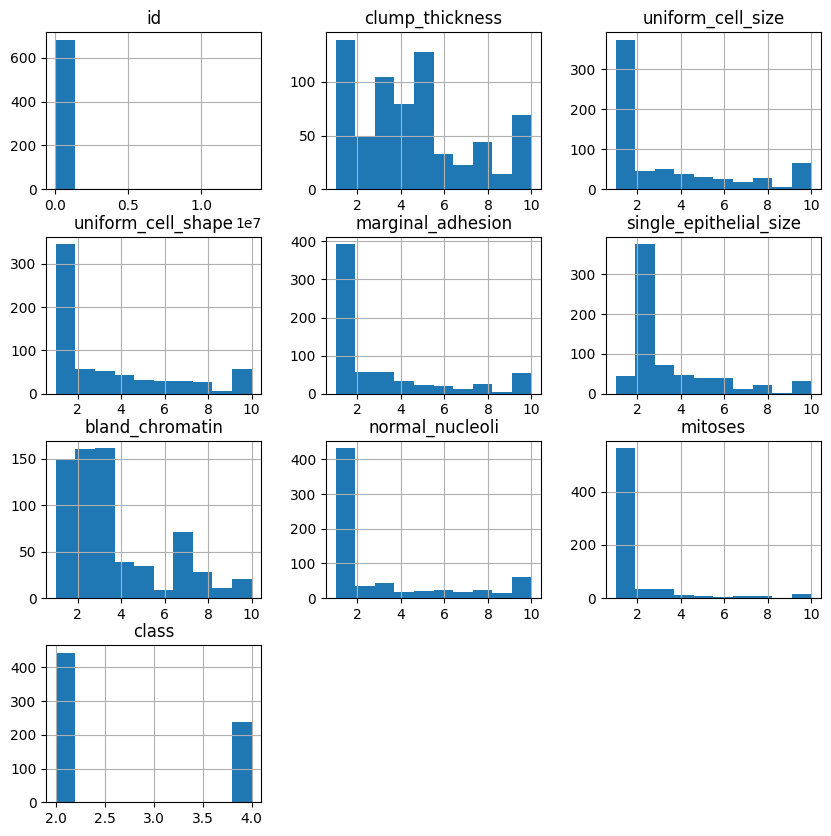

In [ ]:
# Plot histograms for each variable
df.hist(figsize = (10, 10))
plt.show()

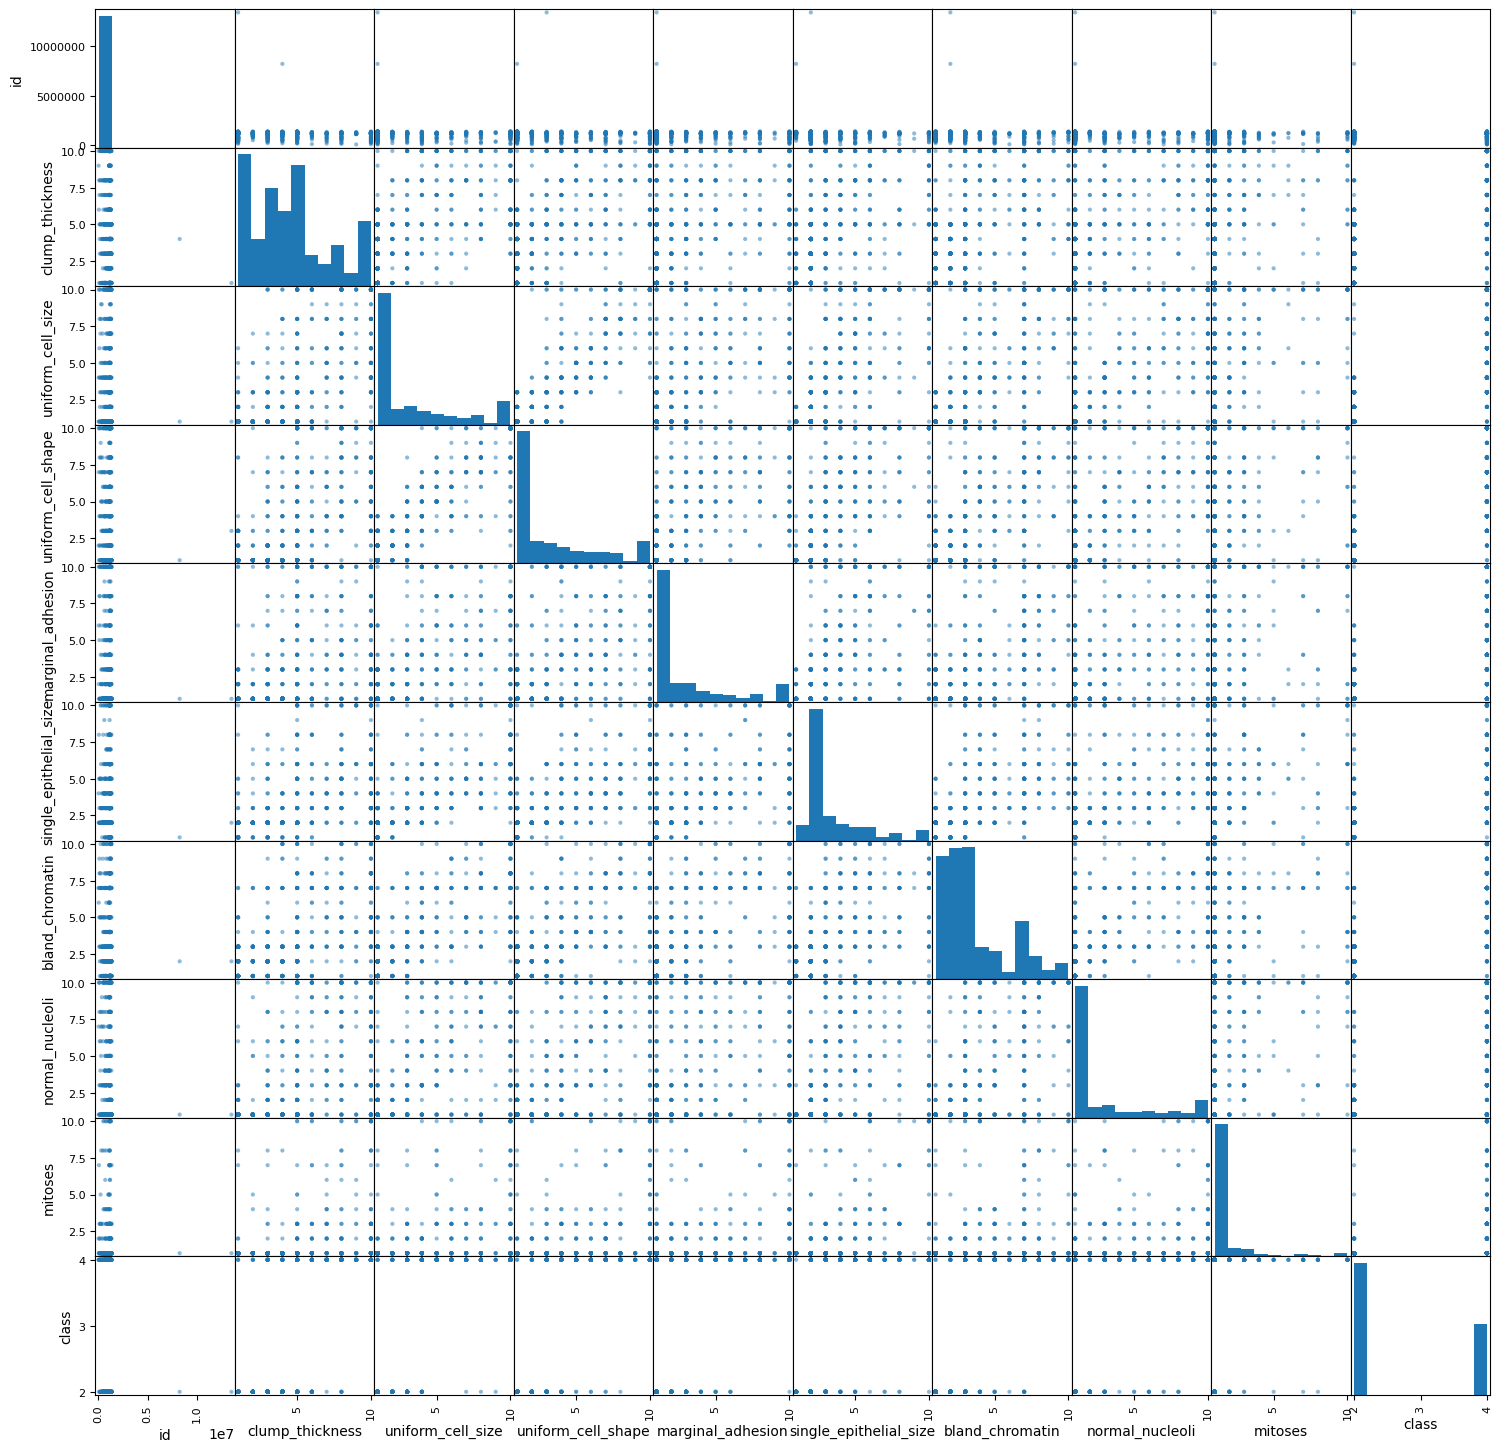

In [ ]:
# Create scatter plot matrix
scatter_matrix(df, figsize = (18,18))
plt.show()

In [ ]:
# Create X and Y datasets for training
X = np.array(df.drop(columns=['class']))
y = np.array(df['class'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Testing Options
seed = 8
scoring = 'accuracy'

In [ ]:
# Define models to train
models = []
models.append(('KNN', KNeighborsClassifier(n_neighbors = 5)))
models.append(('SVM', SVC()))

# evaluate each model in turn
results = []
names = []

for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state = seed)
    cv_results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")
    #print(msg)


KNN: 0.5934 (0.0607)
SVM: 0.6687 (0.0664)


In [ ]:
# Make predictions on validation dataset

for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(name)
    print(accuracy_score(y_test, predictions))
    print(classification_report(y_test, predictions))

# Accuracy - ratio of correctly predicted observation to the total observations.
# Precision - (false positives) ratio of correctly predicted positive observations to the total predicted positive observations
# Recall (Sensitivity) - (false negatives) ratio of correctly predicted positive observations to the all observations in actual class - yes.
# F1 score - F1 Score is the weighted average of Precision and Recall. Therefore, this score takes both false positives and false

KNN
0.6131386861313869
              precision    recall  f1-score   support

           2       0.62      0.84      0.71        79
           4       0.58      0.31      0.40        58

    accuracy                           0.61       137
   macro avg       0.60      0.57      0.56       137
weighted avg       0.60      0.61      0.58       137

SVM
0.5766423357664233
              precision    recall  f1-score   support

           2       0.58      1.00      0.73        79
           4       0.00      0.00      0.00        58

    accuracy                           0.58       137
   macro avg       0.29      0.50      0.37       137
weighted avg       0.33      0.58      0.42       137



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Train the model
clf = SVC()
clf.fit(X_train, y_train)

# Evaluate accuracy
accuracy = clf.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")

# Example prediction (must match number of features in X)
example_measures = np.array([[4, 2, 1, 1, 1, 2, 3, 2, 1, 1]])
prediction = clf.predict(example_measures)
print(f"Prediction: {prediction [0]}")

Accuracy: 0.5766
Prediction: 2


In [ ]:
print(X_train.shape)

(546, 10)
